In [41]:
import matplotlib.pyplot as plt
import muon
import numpy as np
import requests
import scanpy as sc
import scipy
import scvi
import seaborn as sns
import torch
import re
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import davies_bouldin_score
import pandas as pd

In [3]:
torch.set_float32_matmul_precision("high")

/opt/anaconda3/lib/python3.13/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:85.)
  _C._set_float32_matmul_precision(precision)


# Read Data

In [4]:
# mdata = muon.read_h5mu("../../data/tonsil/tonsil_pp.h5mu")
mdata = muon.read_h5mu("../../data/tonsil/tonsil_pp_svg.h5mu")

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [5]:
scvi.model.TOTALVI.setup_mudata(mdata, modalities={'rna_layer': 'RNA',
                                                   'protein_layer': 'Protein'
                                                   })

# Run TotalVI

In [ ]:
# model = scvi.model.TOTALVI.load("../results/vanilla_totalVI.pt", adata=mdata)

INFO     File ../results/vanilla_totalVI.pt/model.pt already downloaded                                            
INFO     Computing empirical prior initialization for protein background.                                          


/opt/anaconda3/lib/python3.13/site-packages/scvi/model/base/_base_model.py:812: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


In [6]:
model = scvi.model.TOTALVI(mdata)

INFO     Computing empirical prior initialization for protein background.                                          


In [7]:
model.train(early_stopping = True)

/opt/anaconda3/lib/python3.13/site-packages/scvi/train/_trainrunner.py:84: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/core/optimizer.py:317: The lr scheduler dict contains the key(s) ['monitor'], but the keys will be ignored. You need to call `lr_scheduler.step()` manually in manual optimization.
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does n

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [8]:
rna = mdata.mod["RNA"]
protein = mdata.mod["Protein"]

In [9]:
# arbitrarily store latent in rna modality
TOTALVI_LATENT_KEY = "X_totalVI"
rna.obsm[TOTALVI_LATENT_KEY] = model.get_latent_representation()

In [11]:
rna_denoised, protein_denoised = model.get_normalized_expression(n_samples=25, return_mean=True)
rna.layers["denoised_rna"] = rna_denoised
protein.layers["denoised_protein"] = protein_denoised

protein.layers["protein_foreground_prob"] = 100 * model.get_protein_foreground_probability(
    n_samples=25, return_mean=True
)
parsed_protein_names = [re.sub(pattern = "\.[ATGC]*$", repl = "", string = p) for p in protein.var_names]
protein.var["clean_names"] = parsed_protein_names
mdata.update()

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [12]:
TOTALVI_CLUSTERS_KEY = "leiden_totalVI"
TOTALVI_CLUSTERS_KEY_LOUVAIN = "louvain_totalVI"
TOTALVI_CLUSTERS_KEY_KMEANS = "kmeans_totalVI"

sc.pp.neighbors(rna, use_rep=TOTALVI_LATENT_KEY)
sc.tl.umap(rna)
sc.tl.leiden(rna, key_added=TOTALVI_CLUSTERS_KEY, resolution= 0.7)
sc.tl.louvain(rna, key_added=TOTALVI_CLUSTERS_KEY_LOUVAIN, resolution = 0.7)

kmeans_mod = KMeans(n_clusters=5, random_state=0).fit(rna.obsm['X_totalVI'])
rna.obs[TOTALVI_CLUSTERS_KEY_KMEANS] = kmeans_mod.labels_.astype(str)

/var/folders/td/snqs86gn12g5nxg94yl2nhrr0000gn/T/ipykernel_45495/198208967.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna, key_added=TOTALVI_CLUSTERS_KEY, resolution= 0.7)


In [13]:
mdata.update()

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [14]:
model.save("../results/vanilla_totalVI.pt", overwrite=True)

In [15]:
mdata.write_h5mu("../results/vanilla_totalVI.h5mu")

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


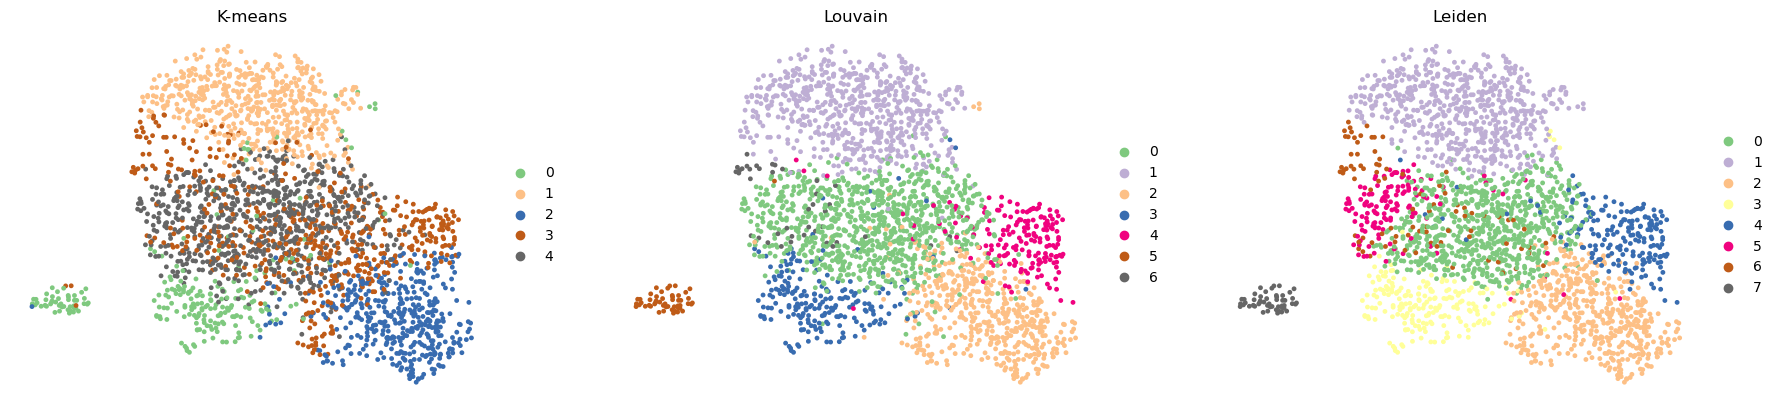

In [36]:
rna_umap_plot = muon.pl.embedding(
    mdata,
    basis="RNA:X_umap",
    color=[f"RNA:{TOTALVI_CLUSTERS_KEY_KMEANS}",f"RNA:{TOTALVI_CLUSTERS_KEY_LOUVAIN}", f"RNA:{TOTALVI_CLUSTERS_KEY}"],
    frameon = False,
    palette = 'Accent',
    title = ['K-means', 'Louvain', 'Leiden'],
    return_fig=True
)

In [17]:
rna_umap_plot.savefig("../results/vanilla_totalVI_UMAP.pdf")
rna_umap_plot.savefig("../results/vanilla_totalVI_UMAP.png", dpi = 300)

# x-y position plots

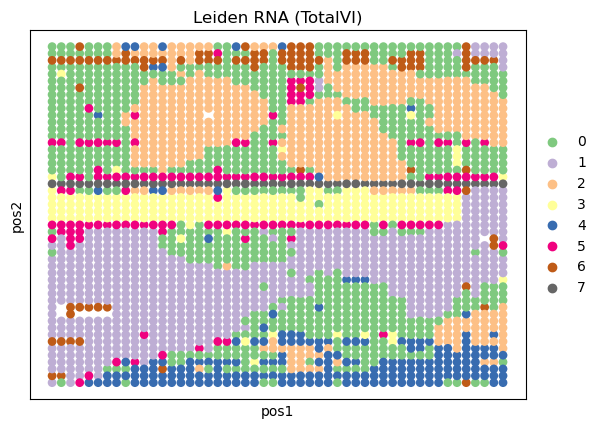

In [37]:

rna_pos_plot = sc.pl.embedding(mdata.mod['RNA'],
                                basis="pos",
                                color=TOTALVI_CLUSTERS_KEY, 
                                s=160,
                                return_fig=True,
                                title = 'Leiden RNA (TotalVI)',
                                palette= "Accent")

In [38]:
rna_pos_plot.axes[0].invert_yaxis()

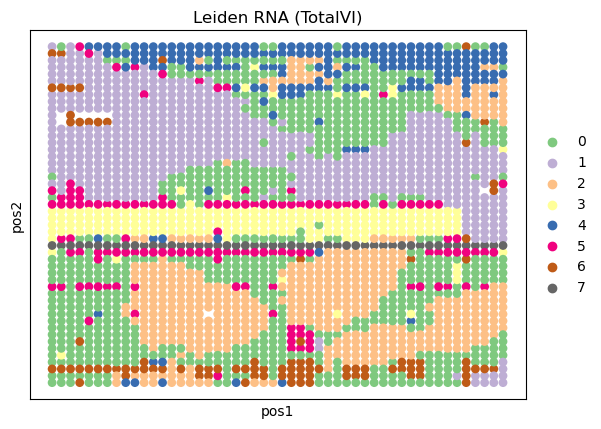

In [39]:
rna_pos_plot

In [40]:
rna_pos_plot.set_size_inches(w = 6, h = 6)
rna_pos_plot.savefig("../results/RNA_position_vanilla_totalVI_leiden_coloured_plot.pdf", bbox_inches='tight')

# Moran's I

In [42]:
moran_i = sc.metrics.morans_i(rna, obsm="X_totalVI")

In [43]:
pd.DataFrame(data = {'Moran_I_vanilla_totalVI': moran_i}).to_csv("../results/Moran_I_metrics_vanilla_totalVI.csv", index = False)

# LISI

In [44]:
def compute_lisi(emb, labels, perplexity=30):
    n_neighbors = int(3 * perplexity)
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(emb)
    distances, indices = nn.kneighbors(emb)
    indices = indices[:, 1:]

    labels = np.array(labels)
    out = []

    for i in range(emb.shape[0]):
        neigh = labels[indices[i]]
        p = pd.value_counts(neigh) / len(neigh)
        entropy = -(p * np.log(p)).sum()
        out.append(np.exp(entropy))

    return np.array(out)

In [45]:
rna.obs["cLISI_kmeans5"] = compute_lisi(rna.obsm["X_totalVI"], rna.obs["kmeans_totalVI"])
rna.obs["cLISI_louvain"] = compute_lisi(rna.obsm["X_totalVI"], rna.obs["louvain_totalVI"])
rna.obs["cLISI_leiden"] = compute_lisi(rna.obsm["X_totalVI"], rna.obs["leiden_totalVI"])

/var/folders/td/snqs86gn12g5nxg94yl2nhrr0000gn/T/ipykernel_45495/3353607529.py:12: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/td/snqs86gn12g5nxg94yl2nhrr0000gn/T/ipykernel_45495/3353607529.py:12: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/td/snqs86gn12g5nxg94yl2nhrr0000gn/T/ipykernel_45495/3353607529.py:12: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/td/snqs86gn12g5nxg94yl2nhrr0000gn/T/ipykernel_45495/3353607529.py:12: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.v

In [46]:
rna.obs[['cLISI_kmeans5', 'cLISI_louvain', 'cLISI_leiden']].to_csv("../results/LISI_metrics_vanilla_totalVI.csv")

# DBI

In [47]:
# Extract embedding and labels
X = rna.obsm["X_totalVI"]
labels = rna.obs["leiden"].astype(int).values

In [48]:
dbi_list = []

# compute DBI for each single PC (1D DBI)
for i in range(X.shape[1]):
    Xi = X[:, i].reshape(-1, 1)
    dbi_list.append(davies_bouldin_score(Xi, labels))

dbi_list = np.array(dbi_list)
print(dbi_list)

[ 29.06499108 104.53740439  73.40752783  80.82860099 130.66422315
 102.88380861  47.56314121  16.47207496 152.32976515  41.83229759
 127.48910199  51.99763969  38.12754526 258.07077199  72.79980522
 153.55838754  59.46499832 102.93172912  13.71436358 518.39986893]


In [49]:
pd.DataFrame(data = {"DBI_leiden": dbi_list}).to_csv("../results/DBI_vanilla_totalVI_metrics.csv", index = False)

# DE

In [31]:
# de_df = model.differential_expression(
#     groupby="RNA:leiden_totalVI", delta=0.5, batch_correction=True
# )
# de_df.head(5)

In [32]:
# filtered_pro = {}
# filtered_rna = {}
# cats = rna.obs[TOTALVI_CLUSTERS_KEY].cat.categories
# for c in cats:
#     cid = f"{c} vs Rest"
#     cell_type_df = de_df.loc[de_df.comparison == cid]
#     cell_type_df = cell_type_df.sort_values("lfc_median", ascending=False)

#     cell_type_df = cell_type_df[cell_type_df.lfc_median > 0]

#     pro_rows = cell_type_df.index.str.contains("protein")
#     data_pro = cell_type_df.iloc[pro_rows]
#     data_pro = data_pro[data_pro["bayes_factor"] > 0.7]

#     data_rna = cell_type_df.iloc[~pro_rows]
#     data_rna = data_rna[data_rna["bayes_factor"] > 3]
#     data_rna = data_rna[data_rna["non_zeros_proportion1"] > 0.1]

#     filtered_pro[c] = data_pro.index.tolist()[:3]
#     filtered_rna[c] = data_rna.index.tolist()[:2]

In [33]:
# sc.tl.dendrogram(rna, groupby=TOTALVI_CLUSTERS_KEY, use_rep=TOTALVI_LATENT_KEY)

In [34]:
# [item for sublist in list(filtered_rna.values()) for item in sublist]

In [35]:
# sc.pl.heatmap(rna, var_names = [item for sublist in list(filtered_rna.values()) for item in sublist], groupby=TOTALVI_CLUSTERS_KEY, use_raw = False, log = True)

In [36]:
# # For protein data
# protein.obs[TOTALVI_CLUSTERS_KEY] = rna.obs[TOTALVI_CLUSTERS_KEY]
# protein.obsm[TOTALVI_LATENT_KEY] = rna.obsm[TOTALVI_LATENT_KEY]
# sc.tl.dendrogram(protein, groupby=TOTALVI_CLUSTERS_KEY, use_rep=TOTALVI_LATENT_KEY)

In [37]:
# filtered_pro_cleaned = [item for sublist in list(filtered_pro.values()) for item in sublist]
# filtered_pro_cleaned = [re.sub('\.[ATGC]*_protein', repl = '', string = item) for item in filtered_pro_cleaned]

In [ ]:
# GOD I hate the python version of scRNAseq analysis it's so messy

## Wilcoxon Rank-Sum

- To be able to compare with our spatial totalVI that doesn't use the totalVI model

In [50]:
# Normalizing to median total counts
sc.pp.normalize_total(rna)
# Logarithmize the data
sc.pp.log1p(rna)

In [51]:
plt.style.use('default')

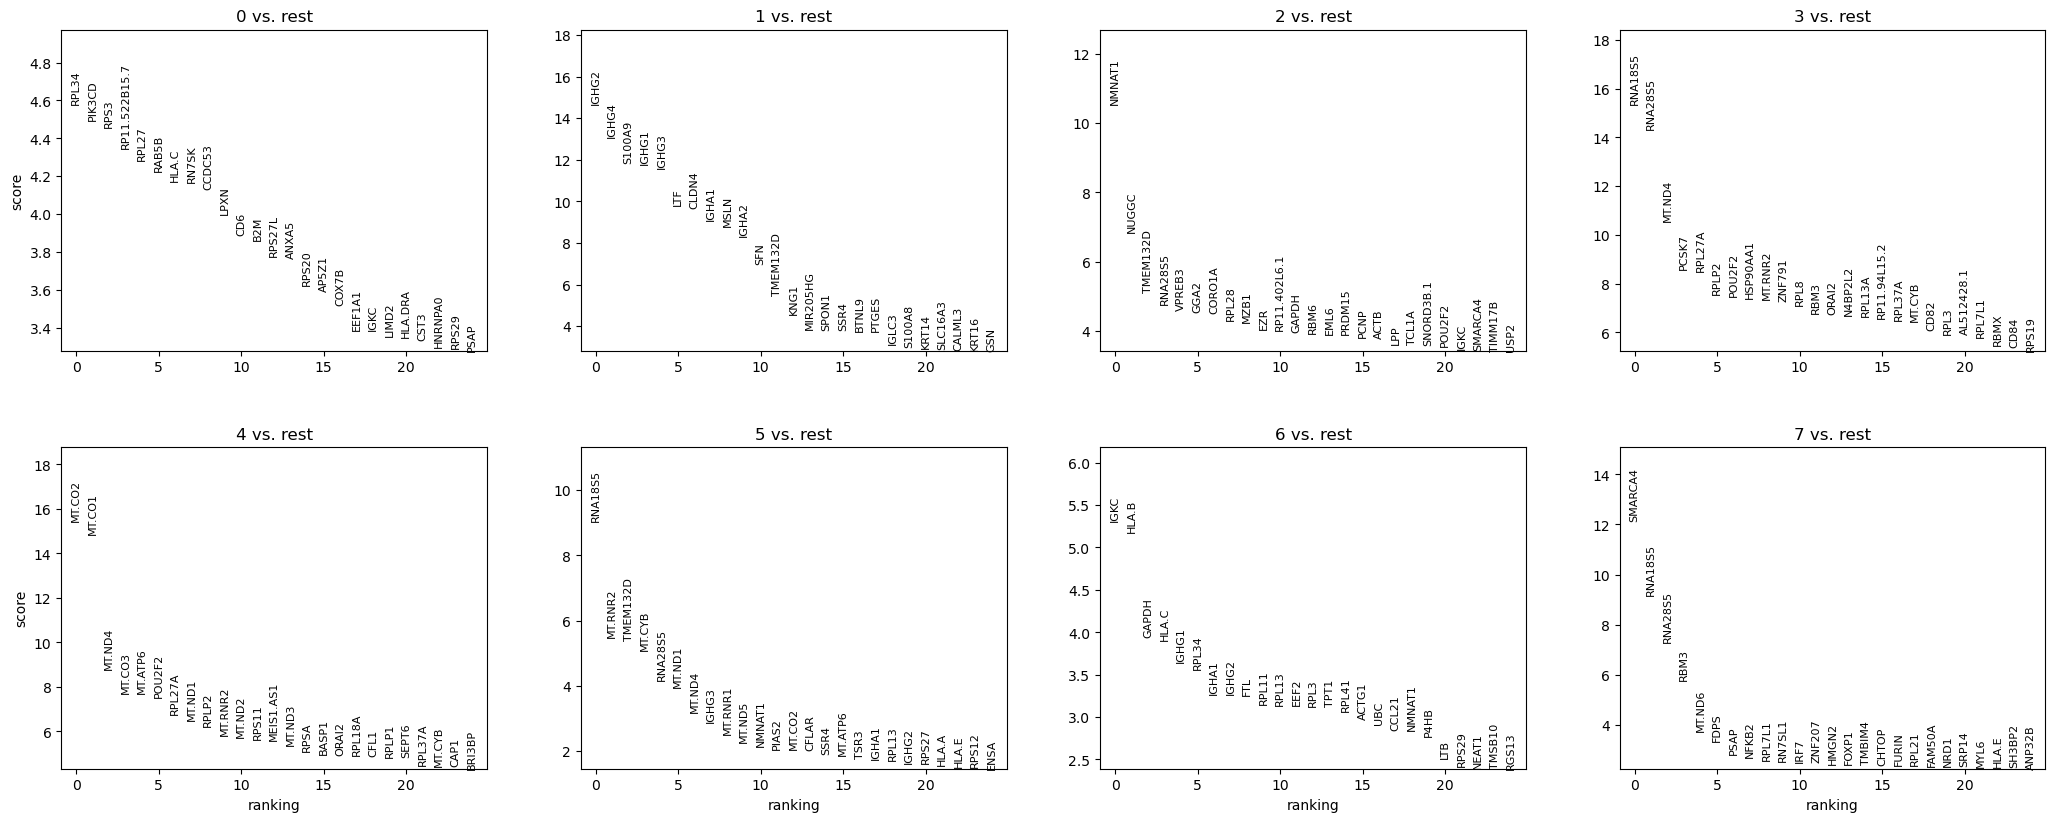

In [52]:
sc.tl.rank_genes_groups(rna, 'leiden_totalVI', method='wilcoxon', key_added = "wilcoxon")
sc.pl.rank_genes_groups(rna, n_genes=25, sharey=False, key="wilcoxon")

In [53]:
rna_dotplot = sc.pl.rank_genes_groups_dotplot(rna,
                                              n_genes=8, 
                                              values_to_plot="logfoldchanges",
                                              key="wilcoxon",
                                              groupby="leiden_totalVI",
                                              cmap = "RdBu_r",
                                              vmin = -1.25,
                                              vcenter = 0,
                                              vmax =1.25,
                                              return_fig = True
                                              )

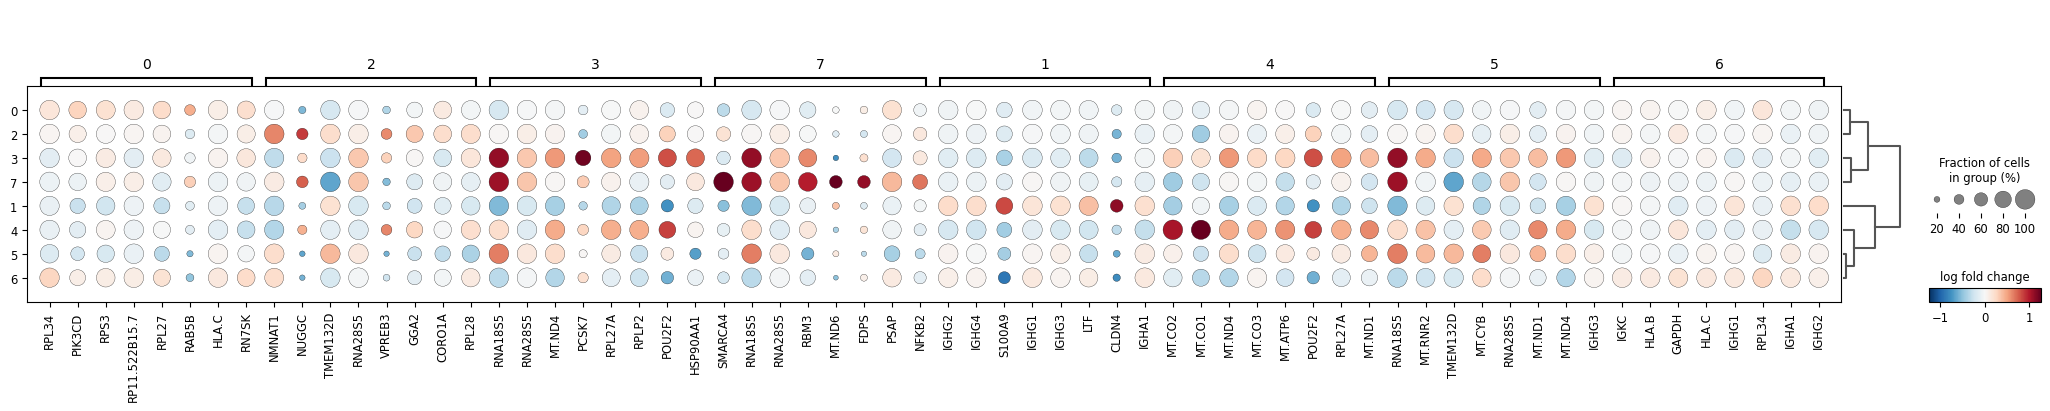

In [54]:
rna_dotplot.show()

In [55]:
rna_dotplot.fig.set_size_inches(w = 18, h = 6)
rna_dotplot.fig.savefig("../results/vanilla_totalVI_RNA_DE_dotplot.pdf", bbox_inches="tight")
rna_dotplot.fig.savefig("../results/vanilla_totalVI_RNA_DE_dotplot.png", bbox_inches="tight", dpi = 300)